Получение данных:

In [1]:
!pip install kagglehub

In [2]:
import kagglehub

path = kagglehub.dataset_download("kmader/skin-cancer-mnist-ham10000")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'skin-cancer-mnist-ham10000' dataset.
Path to dataset files: /kaggle/input/skin-cancer-mnist-ham10000


In [3]:
import os
import cv2

def preprocess_dataset_simple(source_dir, target_dir, target_folders, target_size=(224, 224)):
    os.makedirs(target_dir, exist_ok=True)
    path_mapping = {}
    counter = 0
    for folder in target_folders:
        current_source_folder = os.path.join(source_dir, folder)
        if not os.path.exists(current_source_folder):
            print(f"Предупреждение: Папка {current_source_folder} не найдена!")
            continue

        for file in os.listdir(current_source_folder):
            if file.lower().endswith(('.png', '.jpg', '.jpeg', '.webp')):
                old_path = os.path.join(current_source_folder, file)
                new_path = os.path.join(target_dir, file)
                img = cv2.imread(old_path)
                if img is None:
                    print(f"Пропущен битый файл: {old_path}")
                    continue

                img_resized = cv2.resize(img, target_size)
                cv2.imwrite(new_path, img_resized, [int(cv2.IMWRITE_JPEG_QUALITY), 95])
                filename_without_ext, _ = os.path.splitext(file)
                path_mapping[filename_without_ext] = new_path
                counter += 1
                if counter % 500 == 0:
                    print(f"Обработано картинок: {counter}")

    print(f"Успешно обработано всего картинок: {counter}")
    return path_mapping

In [4]:
from pathlib import Path

result_path = Path("/kaggle/working/resized")
result_path.mkdir(parents=True, exist_ok=False)

TARGET_SIZE = (224, 224)
subfolders = ["HAM10000_images_part_1", "HAM10000_images_part_2"]
imageid_path_dict = preprocess_dataset_simple(path, result_path, subfolders, TARGET_SIZE)

Обработано картинок: 500
Обработано картинок: 1000
Обработано картинок: 1500
Обработано картинок: 2000
Обработано картинок: 2500
Обработано картинок: 3000
Обработано картинок: 3500
Обработано картинок: 4000
Обработано картинок: 4500
Обработано картинок: 5000
Обработано картинок: 5500
Обработано картинок: 6000
Обработано картинок: 6500
Обработано картинок: 7000
Обработано картинок: 7500
Обработано картинок: 8000
Обработано картинок: 8500
Обработано картинок: 9000
Обработано картинок: 9500
Обработано картинок: 10000
Успешно обработано всего картинок: 10015


Словарь имя файла - путь к файлу:

Наименования видов поражения:

In [5]:
lesion_type_dict = {
    'nv': 'Melanocytic nevi',
    'mel': 'Melanoma',
    'bkl': 'Benign keratosis-like lesions',
    'bcc': 'Basal cell carcinoma',
    'akiec': 'Actinic keratoses',
    'vasc': 'Vascular lesions',
    'df': 'Dermatofibroma'
}

Таблица признаков и путей к файлам:

In [6]:
import pandas as pd

skin_df = pd.read_csv(os.path.join(path, 'HAM10000_metadata.csv'))
skin_df['path'] = skin_df['image_id'].map(imageid_path_dict.get)
skin_df['cell_type'] = skin_df['dx'].map(lesion_type_dict.get)
skin_df['cell_type_idx'] = pd.Categorical(skin_df['cell_type']).codes
skin_df.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization,path,cell_type,cell_type_idx
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,/kaggle/working/resized/ISIC_0027419.jpg,Benign keratosis-like lesions,2
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,/kaggle/working/resized/ISIC_0025030.jpg,Benign keratosis-like lesions,2
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,/kaggle/working/resized/ISIC_0026769.jpg,Benign keratosis-like lesions,2
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,/kaggle/working/resized/ISIC_0025661.jpg,Benign keratosis-like lesions,2
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,/kaggle/working/resized/ISIC_0031633.jpg,Benign keratosis-like lesions,2


Индексы видов поражения:

In [7]:
leison_type_index_mapping = dict(enumerate(pd.Categorical(skin_df['cell_type']).categories))
leison_type_index_mapping

{0: 'Actinic keratoses',
 1: 'Basal cell carcinoma',
 2: 'Benign keratosis-like lesions',
 3: 'Dermatofibroma',
 4: 'Melanocytic nevi',
 5: 'Melanoma',
 6: 'Vascular lesions'}

In [8]:
import numpy as np
import tensorflow as tf
from keras.utils import Sequence
from sklearn.model_selection import train_test_split

class ImageDatasetGenerator(Sequence):
    def __init__(self, file_paths, labels, batch_size=32, num_classes=None, shuffle=False):
        self.file_paths = np.array(file_paths)
        self.labels = tf.keras.utils.to_categorical(labels, num_classes=num_classes)
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.indices = np.arange(len(self.file_paths))
        self.on_epoch_end()

    def __len__(self):
        return int(np.ceil(len(self.file_paths) / self.batch_size))

    def __getitem__(self, idx):
        start = idx * self.batch_size
        end = min((idx + 1) * self.batch_size, len(self.file_paths))
        batch_indices = self.indices[start:end]

        batch_x = []
        for file_path in self.file_paths[batch_indices]:
            img = cv2.imread(file_path)

            if img is None:
                raise FileNotFoundError(f"Не удалось прочитать файл: {file_path}")

            img = img.astype(np.float32) / 255.0
            batch_x.append(img)

        batch_x = np.array(batch_x)
        batch_y = self.labels[batch_indices]

        return batch_x, batch_y

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)

In [9]:
all_paths = skin_df['path'].values
all_labels = skin_df['cell_type_idx'].values
num_classes = len(np.unique(all_labels))

Разбиение на обучающую и тестовую выборку:

In [10]:
train_val_paths, test_paths, train_val_labels, test_labels = train_test_split(
    all_paths, all_labels,
    test_size=0.20,
    random_state=42,
    stratify=all_labels
)
train_paths, val_paths, train_labels, val_labels = train_test_split(
    train_val_paths, train_val_labels,
    test_size=0.20,
    random_state=42,
    stratify=train_val_labels
)

print(f"Train: {len(train_paths)}, Val: {len(val_paths)}, Test: {len(test_paths)}")

Train: 6409, Val: 1603, Test: 2003


In [11]:
BATCH_SIZE = 32

train_generator = ImageDatasetGenerator(
    train_paths, train_labels, batch_size=BATCH_SIZE, shuffle=True
)

val_generator = ImageDatasetGenerator(
    val_paths, val_labels, batch_size=BATCH_SIZE, shuffle=False
)

test_generator = ImageDatasetGenerator(
    test_paths, test_labels, batch_size=BATCH_SIZE, shuffle=False
)

Метрики качества:

In [12]:
import itertools
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    plt.figure(figsize=(7, 7))
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=90)
    plt.yticks(tick_marks, classes)

    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, cm[i, j],
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

def print_classification_report(y_true, y_pred, target_names):
  print(classification_report(y_true, np.argmax(y_pred, axis=1), target_names=target_names))

def print_results(model, test_generator, target_names):
    y_pred = model.predict(test_generator)
    y_pred_classes = np.argmax(y_pred, axis=1)
    y_true = np.argmax(test_generator.labels, axis=1)
    confusion_mtx = confusion_matrix(y_true, y_pred_classes)
    plot_confusion_matrix(confusion_mtx, target_names)
    print_classification_report(y_true, y_pred, target_names)

Простая CNN-модель:

In [13]:
import keras
from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPool2D, Activation, Input
from keras import backend as K
import itertools
from keras.layers import BatchNormalization

from keras.optimizers import Adam
from keras.callbacks import ReduceLROnPlateau
from sklearn.model_selection import train_test_split

import math

input_shape = TARGET_SIZE + (3,)
num_classes = 7

model = Sequential()
model.add(Input(shape=input_shape))
model.add(Conv2D(32, kernel_size=(3, 3), padding='same'))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(Conv2D(32, kernel_size=(3, 3), padding='same'))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(MaxPool2D(pool_size=(2, 2)))
model.add(Dropout(0.2))

model.add(Conv2D(64, kernel_size=(3, 3), padding='same'))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(Conv2D(64, kernel_size=(3, 3), padding='same'))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(MaxPool2D(pool_size=(2, 2)))
model.add(Dropout(0.2))

model.add(Flatten())
model.add(Dense(64))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(Dropout(0.2))

model.add(Dense(num_classes, activation='softmax'))
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 200704)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │    12,845,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴─────────────

 Total params: 12,912,167 (49.26 MB)

 Trainable params: 12,911,655 (49.25 MB)

 Non-trainable params: 512 (2.00 KB)

In [14]:
from keras.callbacks import EarlyStopping, ReduceLROnPlateau

callbacks = [
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=10,
        verbose=1,
        min_lr=1e-6
    ),
    EarlyStopping(
        monitor='val_loss',
        mode='min',
        patience=20,
        restore_best_weights=True,
        verbose=1
    )
]

In [ ]:
model.compile(optimizer=Adam(), loss="categorical_crossentropy", metrics=["accuracy"])

model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=100,
    callbacks=callbacks,
    verbose = 1
)

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


201/201 ━━━━━━━━━━━━━━━━━━━━ 57s 182ms/step - accuracy: 0.6517 - loss: 1.0546 - val_accuracy: 0.4554 - val_loss: 1.5467 - learning_rate: 0.0010
Epoch 2/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 26s 129ms/step - accuracy: 0.7113 - loss: 0.7963 - val_accuracy: 0.6082 - val_loss: 1.0042 - learning_rate: 0.0010
Epoch 3/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 27s 135ms/step - accuracy: 0.7262 - loss: 0.7397 - val_accuracy: 0.7330 - val_loss: 0.7286 - learning_rate: 0.0010
Epoch 4/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 29s 144ms/step - accuracy: 0.7430 - loss: 0.6881 - val_accuracy: 0.7093 - val_loss: 0.8795 - learning_rate: 0.0010
Epoch 5/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 27s 136ms/step - accuracy: 0.7611 - loss: 0.6487 - val_accuracy: 0.7199 - val_loss: 0.7805 - learning_rate: 0.0010
Epoch 6/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 27s 133ms/step - accuracy: 0.7800 - loss: 0.5945 - val_accuracy: 0.7012 - val_loss: 0.8125 - learning_rate: 0.0010
Epoch 7/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 27s 137ms/step - accuracy: 0.8017 -

63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 74ms/step
                               precision    recall  f1-score   support

            Actinic keratoses       0.48      0.22      0.30        65
         Basal cell carcinoma       0.58      0.43      0.49       103
Benign keratosis-like lesions       0.41      0.42      0.41       220
               Dermatofibroma       0.00      0.00      0.00        23
             Melanocytic nevi       0.80      0.93      0.86      1341
                     Melanoma       0.47      0.24      0.32       223
             Vascular lesions       1.00      0.18      0.30        28

                     accuracy                           0.73      2003
                    macro avg       0.53      0.34      0.38      2003
                 weighted avg       0.69      0.73      0.70      2003



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


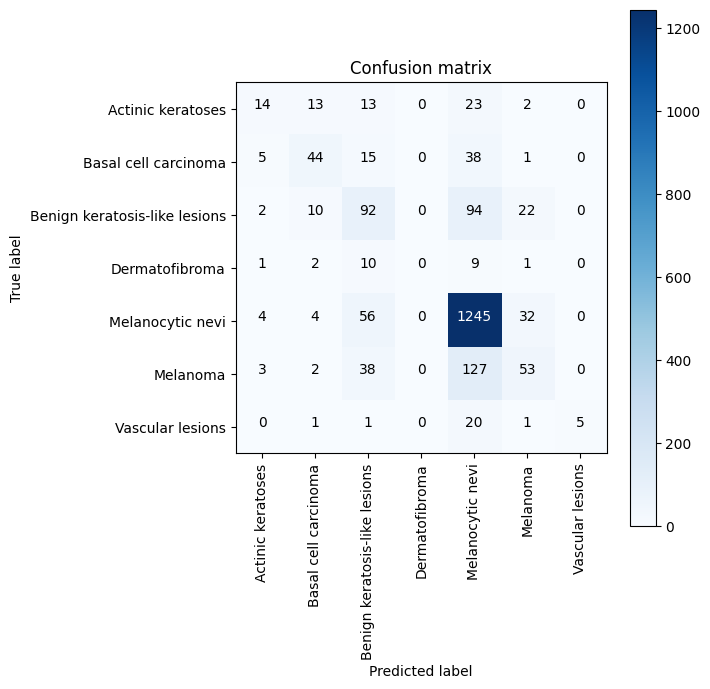

In [ ]:
print_results(model, test_generator, list(leison_type_index_mapping.values()))

In [ ]:
model.save("simple_cnn_model.keras")

CNN-модель с аугментацией данных и балансировкой классов:

In [15]:
from sklearn.utils.class_weight import compute_class_weight

unique_classes = np.unique(np.argmax(train_generator.labels, axis=1))
weights = compute_class_weight(class_weight='balanced', classes=unique_classes, y=np.argmax(train_generator.labels, axis=1))
weights = np.clip(weights, a_min=1.0, a_max=5.0)
class_weight_dict = dict(zip(unique_classes, weights))
class_weight_dict

{np.int64(0): np.float64(4.380724538619275),
 np.int64(1): np.float64(2.782891880156318),
 np.int64(2): np.float64(1.3023775655354604),
 np.int64(3): np.float64(5.0),
 np.int64(4): np.float64(1.0),
 np.int64(5): np.float64(1.2859149277688604),
 np.int64(6): np.float64(5.0)}

In [16]:
from keras.layers import Activation, Input, RandomFlip, RandomRotation, RandomBrightness

model = Sequential()

model.add(Input(shape=input_shape))
model.add(RandomFlip("horizontal_and_vertical"))
model.add(RandomRotation(0.15))

model.add(Conv2D(32, kernel_size=(3, 3), padding='same'))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(Conv2D(32, kernel_size=(3, 3), padding='same'))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(MaxPool2D(pool_size=(2, 2)))
model.add(Dropout(0.2))

model.add(Conv2D(64, kernel_size=(3, 3), padding='same'))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(Conv2D(64, kernel_size=(3, 3), padding='same'))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(MaxPool2D(pool_size=(2, 2)))
model.add(Dropout(0.2))

model.add(Flatten())
model.add(Dense(64))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(Dropout(0.2))

model.add(Dense(num_classes, activation='softmax'))

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip (RandomFlip)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 224, 224, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_8 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 200704)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │    12,845,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_9 (Activation)       │ (None, 64)             │             

 Total params: 12,912,167 (49.26 MB)

 Trainable params: 12,911,655 (49.25 MB)

 Non-trainable params: 512 (2.00 KB)

In [ ]:
model.compile(optimizer=Adam(learning_rate=0.0001, clipnorm=1.0), loss="categorical_crossentropy", metrics=["accuracy"])

model.fit(
    train_generator,
    validation_data=val_generator,
    batch_size=32,
    epochs=100,
    callbacks=callbacks,
    class_weight=class_weight_dict,
    verbose = 1
)

Epoch 1/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 73s 297ms/step - accuracy: 0.4423 - loss: 2.4190 - val_accuracy: 0.0381 - val_loss: 3.3643 - learning_rate: 1.0000e-04
Epoch 2/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 57s 284ms/step - accuracy: 0.5873 - loss: 1.8756 - val_accuracy: 0.2127 - val_loss: 2.4431 - learning_rate: 1.0000e-04
Epoch 3/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 57s 285ms/step - accuracy: 0.6539 - loss: 1.6298 - val_accuracy: 0.5508 - val_loss: 1.4510 - learning_rate: 1.0000e-04
Epoch 4/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 57s 285ms/step - accuracy: 0.6817 - loss: 1.4768 - val_accuracy: 0.6856 - val_loss: 0.9373 - learning_rate: 1.0000e-04
Epoch 5/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 58s 286ms/step - accuracy: 0.7004 - loss: 1.4009 - val_accuracy: 0.7280 - val_loss: 0.8334 - learning_rate: 1.0000e-04
Epoch 6/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 57s 286ms/step - accuracy: 0.7084 - loss: 1.3437 - val_accuracy: 0.7467 - val_loss: 0.7785 - learning_rate: 1.0000e-04
Epoch 7/100
201/201 ━━━━━━━━━━━━━━━━━━━━

63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 61ms/step
                               precision    recall  f1-score   support

            Actinic keratoses       0.73      0.42      0.53        65
         Basal cell carcinoma       0.70      0.37      0.48       103
Benign keratosis-like lesions       0.51      0.63      0.56       220
               Dermatofibroma       0.29      0.48      0.36        23
             Melanocytic nevi       0.83      0.94      0.88      1341
                     Melanoma       0.65      0.20      0.30       223
             Vascular lesions       0.50      0.32      0.39        28

                     accuracy                           0.76      2003
                    macro avg       0.60      0.48      0.50      2003
                 weighted avg       0.75      0.76      0.74      2003



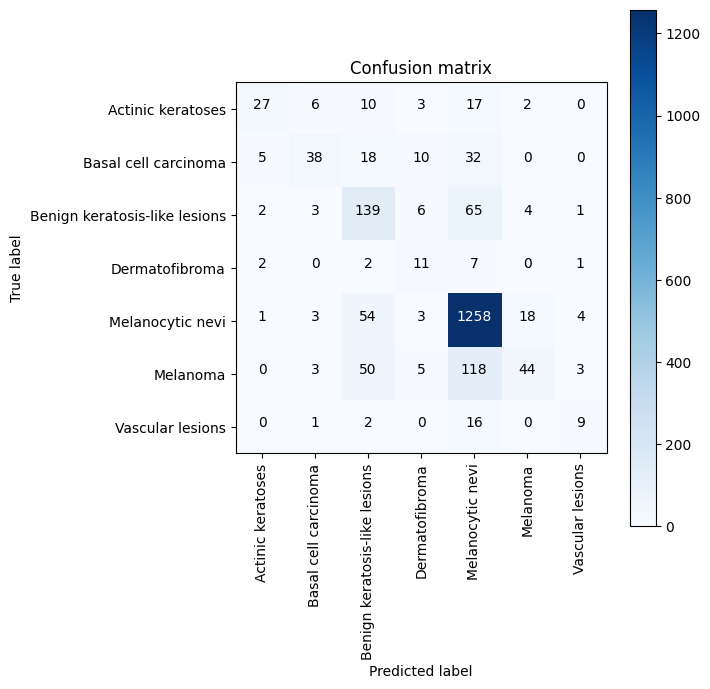

In [ ]:
print_results(model, test_generator, list(leison_type_index_mapping.values()))

In [ ]:
model.save("augmentation_cnn_model.keras")

Модель CNN с переносом обучения:

In [17]:
from keras.applications.resnet50 import ResNet50, preprocess_input
from keras.layers import GlobalAveragePooling2D, Lambda
from keras.applications.densenet import preprocess_input as dense_preprocess
# from keras.applications import DenseNet121
# from keras.applications import EfficientNetB0, EfficientNetB3

model = Sequential()

model.add(Input(shape=input_shape))
model.add(RandomFlip("horizontal_and_vertical"))
model.add(RandomRotation(0.15))

model.add(Lambda(lambda x: preprocess_input(x * 255.0))),

base_model = ResNet50(weights='imagenet', include_top=False, input_shape=input_shape)
base_model.trainable = False
model.add(base_model)

model.add(GlobalAveragePooling2D())
model.add(Dropout(0.2))
model.add(Dense(num_classes, activation='softmax'))

model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip_1 (RandomFlip)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_1               │ (None, 224, 224, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 7)              │        14,343 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,602,055 (90.03 MB)

 Trainable params: 14,343 (56.03 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [18]:
model.compile(optimizer=Adam(learning_rate=0.0001, clipnorm=1.0), loss='categorical_crossentropy', metrics=['accuracy'])

model.fit(
    train_generator,
    validation_data=val_generator,
    batch_size=32,
    epochs=100,
    callbacks=callbacks,
    class_weight=class_weight_dict,
    verbose=1
)

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


201/201 ━━━━━━━━━━━━━━━━━━━━ 48s 175ms/step - accuracy: 0.5113 - loss: 2.5795 - val_accuracy: 0.6594 - val_loss: 0.9921 - learning_rate: 1.0000e-04
Epoch 2/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 33s 162ms/step - accuracy: 0.6385 - loss: 1.8879 - val_accuracy: 0.6862 - val_loss: 0.8900 - learning_rate: 1.0000e-04
Epoch 3/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 33s 167ms/step - accuracy: 0.6595 - loss: 1.7016 - val_accuracy: 0.6893 - val_loss: 0.8494 - learning_rate: 1.0000e-04
Epoch 4/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 34s 170ms/step - accuracy: 0.6706 - loss: 1.5975 - val_accuracy: 0.7062 - val_loss: 0.8142 - learning_rate: 1.0000e-04
Epoch 5/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 34s 170ms/step - accuracy: 0.6897 - loss: 1.5133 - val_accuracy: 0.7205 - val_loss: 0.7841 - learning_rate: 1.0000e-04
Epoch 6/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 35s 175ms/step - accuracy: 0.6982 - loss: 1.4483 - val_accuracy: 0.7168 - val_loss: 0.7784 - learning_rate: 1.0000e-04
Epoch 7/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 35s 176ms/s

63/63 ━━━━━━━━━━━━━━━━━━━━ 22s 245ms/step
                               precision    recall  f1-score   support

            Actinic keratoses       0.49      0.51      0.50        65
         Basal cell carcinoma       0.54      0.59      0.56       103
Benign keratosis-like lesions       0.61      0.60      0.61       220
               Dermatofibroma       0.38      0.65      0.48        23
             Melanocytic nevi       0.90      0.90      0.90      1341
                     Melanoma       0.51      0.45      0.48       223
             Vascular lesions       0.68      0.75      0.71        28

                     accuracy                           0.78      2003
                    macro avg       0.59      0.64      0.61      2003
                 weighted avg       0.78      0.78      0.78      2003



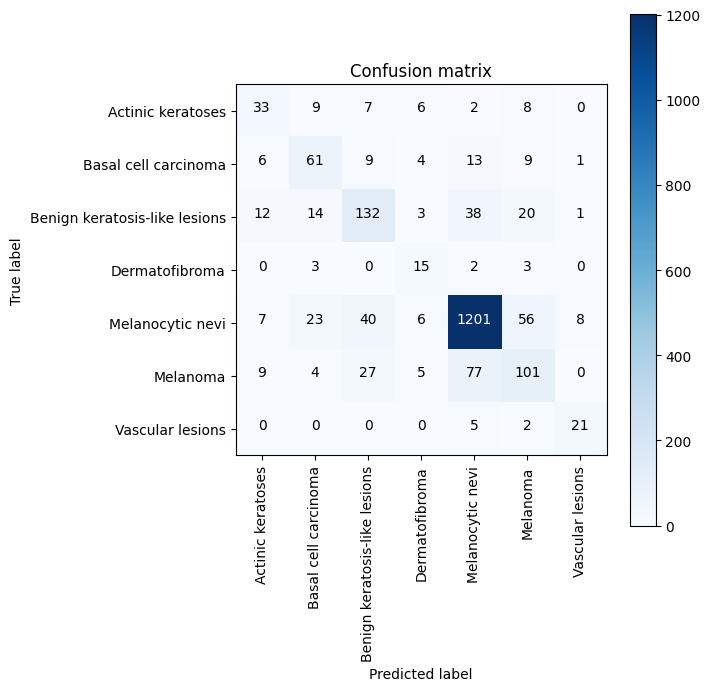

In [19]:
print_results(model, test_generator, list(leison_type_index_mapping.values()))

In [20]:
model.save("transfer_learning_cnn_model.keras")

Модель CNN с переносом обучения и fine-tuning:

In [21]:
base_model.trainable = True

In [22]:
model.compile(optimizer=Adam(learning_rate=0.00001, clipnorm=1.0), loss='categorical_crossentropy', metrics=['accuracy'])

In [23]:
callbacks_fine_tuning = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-7)
]

In [24]:
model.fit(
    train_generator,
    validation_data=val_generator,
    batch_size=32,
    epochs=20,
    callbacks=callbacks_fine_tuning,
    class_weight=class_weight_dict,
    verbose=1
)

Epoch 1/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 172s 625ms/step - accuracy: 0.6981 - loss: 1.5416 - val_accuracy: 0.7767 - val_loss: 0.6785 - learning_rate: 1.0000e-05
Epoch 2/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 120s 599ms/step - accuracy: 0.7566 - loss: 1.0440 - val_accuracy: 0.7742 - val_loss: 0.6295 - learning_rate: 1.0000e-05
Epoch 3/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 120s 598ms/step - accuracy: 0.7881 - loss: 0.8897 - val_accuracy: 0.7991 - val_loss: 0.5873 - learning_rate: 1.0000e-05
Epoch 4/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 121s 601ms/step - accuracy: 0.8075 - loss: 0.7949 - val_accuracy: 0.7966 - val_loss: 0.5886 - learning_rate: 1.0000e-05
Epoch 5/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 120s 595ms/step - accuracy: 0.8348 - loss: 0.6970 - val_accuracy: 0.8122 - val_loss: 0.5539 - learning_rate: 1.0000e-05
Epoch 6/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 120s 598ms/step - accuracy: 0.8419 - loss: 0.6416 - val_accuracy: 0.8079 - val_loss: 0.5490 - learning_rate: 1.0000e-05
Epoch 7/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 

63/63 ━━━━━━━━━━━━━━━━━━━━ 12s 161ms/step
                               precision    recall  f1-score   support

            Actinic keratoses       0.79      0.48      0.60        65
         Basal cell carcinoma       0.82      0.66      0.73       103
Benign keratosis-like lesions       0.66      0.75      0.70       220
               Dermatofibroma       0.60      0.78      0.68        23
             Melanocytic nevi       0.92      0.93      0.92      1341
                     Melanoma       0.60      0.59      0.60       223
             Vascular lesions       0.88      0.82      0.85        28

                     accuracy                           0.84      2003
                    macro avg       0.75      0.71      0.72      2003
                 weighted avg       0.84      0.84      0.84      2003



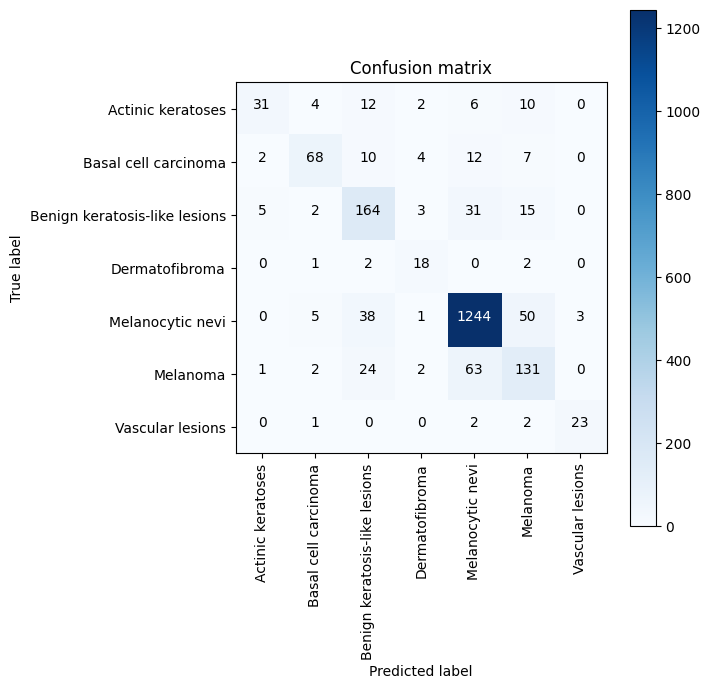

In [25]:
print_results(model, test_generator, list(leison_type_index_mapping.values()))

In [26]:
model.save("fine_tuning_cnn_model.keras")